# 🌍 Building a Climate Scenario Emulator

## Welcome!

This notebook works with the **IPCC AR6 Scenarios Database** which is the dataset underpinning the Sixth Assessment Report on climate change.

Our goal: **build an ML emulator of MAGICC**, a subcomponent of the larger IAMs present in this workspace.

---

### 🎯 What is an emulator?

An emulator (also called a surrogate model) learns to **replicate the input-output behaviour of a more expensive simulator**.

In our case:
- **Simulator:** MAGICC — a physics-based simple climate model. Given a CO₂ emissions trajectory, it computes the resulting probability of exceeding 1.5°C warming, year by year

- **Emulator:** Our ML model — takes the same input, produces the same output, in milliseconds instead of minutes

> A note: MAGICC, as it is built into IAMs is actually already an emulator of a more complicated physics model, allowing quick rendering of temperature targets implicit in these broader socio-economic models. So, we are in a bit of a nesting dolls situation building an emulator of an emulator of a simulator. But, for our purposes don't worry about that too much. The point is to see that models themselves can be used as data. 

---

### 🗺️ Key Concept Mapping

| Term | What it is | Role in this notebook |
| :--- | :--- | :--- |
| **IAM** | Integrated Assessment Model | Produces the emissions scenarios |
| **MAGICC** | Simple climate model | Converts emissions → temperature probabilities. This is the thing we are emulating |
| **Scenario** | One possible future | Each is one training example |
| **CO₂ trajectory** | Input **X** | 17 values: CO₂ at 2020, 2025, …, 2100 |
| **Exceedance probability trajectory** | Target **y** | 17 values: P(exceeding 1.5°C) at each year, as computed by MAGICC |
| **Emulator** | Surrogate model | Learns the mapping X → y |


In [1]:
import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Colour palette matching the lecture slides
DARK_GREEN  = '#0e2a22'
LIGHT_GREEN = '#bfce84'
RED         = '#c1121f'

DATA_PATH = 'AR6-demo-data.csv'

---
## Part 1 — The Big Data Problem 🐢

Our dataset: `AR6-demo-data.csv` — the World-level slice of the AR6 Scenarios Database.

| Property | Value |
| :--- | :--- |
| File size on disk | 345 MB |
| Rows | ~693,000 |
| Columns | 110 (Model, Scenario, Region, Variable, Unit, then 1995–2100) |
| Unique variables | ~400 |

Let's start by trying to load it the way most people first try: with **pandas**.

---
### Step 1 — Load with Pandas

> ⏳ **Warning:** Depending on your system, this could take up to a minute to run.
> Watch your system monitor as you run it. That's the point.

In [3]:
print(f"Attempting to load '{DATA_PATH}' with pandas...")

t0 = time.time()
df_full = pd.read_csv(DATA_PATH)
elapsed = time.time() - t0
mem_gb  = df_full.memory_usage(deep=True).sum() / 1e9

print(f'⏱  Time:   {elapsed:.1f} seconds')
print(f'💾 Memory: {mem_gb:.1f} GB loaded into RAM')
print(f'📐 Shape:  {df_full.shape[0]:,} rows × {df_full.shape[1]} columns')
print()
print('And this is the *smallest* file in the AR6 database.')
print('The full dataset is ~400 GB.')

Attempting to load 'AR6-demo-data.csv' with pandas...
⏱  Time:   2.5 seconds
💾 Memory: 0.8 GB loaded into RAM
📐 Shape:  693,299 rows × 111 columns

And this is the *smallest* file in the AR6 database.
The full dataset is ~400 GB.


In [4]:
del df_full  # free the memory before continuing

---
### Step 2 — DuckDB ⚡

DuckDB is an in-process SQL analytics engine. Think of it as **pandas with SQL, but
smarter about memory**.

| Tool | Strategy | What ends up in RAM |
| :--- | :--- | :--- |
| `pandas.read_csv()` | Load everything, then filter | The whole file |
| DuckDB | Filter *during* the scan, load only the result | Just your answer |

Let's start by just inspecting the file without loading it.

In [5]:
conn = duckdb.connect()

t0 = time.time()
summary = conn.execute(f'''
    SELECT
        COUNT(*)                 AS total_rows,
        COUNT(DISTINCT Model)    AS n_models,
        COUNT(DISTINCT Scenario) AS n_scenarios,
        COUNT(DISTINCT Variable) AS n_variables
    FROM read_csv(\'{DATA_PATH}\', header=true)
''').fetchdf()
elapsed = time.time() - t0

print(f'⚡ Done in {elapsed:.2f} seconds without loading the file into RAM!')
summary

⚡ Done in 0.45 seconds without loading the file into RAM!


,total_rows,n_models,n_scenarios,n_variables
0,693299,109,939,1393


---
## Part 2 — Extract What We Need 🎯

The full file has ~400 distinct variables. For this small emulator, we need two:

| Variable | What it is | Role |
| :--- | :--- | :--- |
| `Emissions\|CO2` | Annual CO₂ emissions (Mt CO₂/yr) | **Input X** — the trajectory the emulator receives |
| `AR6 climate diagnostics\|Exceedance Probability 1.5C\|MAGICCv7.5.3` | P(exceeding 1.5°C) per year | **Target y** — what MAGICC computed, and what the emulator must reproduce |

> 💡 **Why exceedance probability?** The Paris Agreement targets 1.5°C and 2°C warming limits.
> P(exceeding 1.5°C warming) in a given year is MAGICC's primary policy-relevant output — it
> directly answers "how likely is it that this scenario breaches the Paris Agreement target?"
> We could also emulate the median temperature or the full distribution, but exceedance
> probability is the most interpretable single metric for policy analysis.
>
> **Why MAGICC specifically?** IAMs produce emissions trajectories; they don't run a climate
> model internally. MAGICC is the post-processor: given those trajectories, it computes the
> temperature response. The AR6 database stores MAGICC's pre-computed outputs, so we can
> treat them as ground truth without needing to run MAGICC ourselves.

---
### Step 3 — Query with DuckDB

In [6]:
VAR_CO2 = 'Emissions|CO2'
VAR_EXC = 'AR6 climate diagnostics|Exceedance Probability 1.5C|MAGICCv7.5.3'

# ── CO₂ emissions ────────────────────────────────────────────────────────────
t0 = time.time()
df_co2 = conn.execute(f'''
    SELECT *
    FROM read_csv(\'{DATA_PATH}\', header=true)
    WHERE Variable = \'{VAR_CO2}\'
''').fetchdf()
print(f'CO₂ query: {time.time()-t0:.2f}s  →  {df_co2.shape[0]:,} scenarios loaded')

# ── 1.5°C exceedance probability ─────────────────────────────────────────────
t0 = time.time()
df_exc = conn.execute(f'''
    SELECT *
    FROM read_csv(\'{DATA_PATH}\', header=true)
    WHERE Variable = \'{VAR_EXC}\'
''').fetchdf()
print(f'Exceedance query: {time.time()-t0:.2f}s  →  {df_exc.shape[0]:,} scenarios loaded')

# The year columns we'll keep (every 5 years — enough temporal resolution)
YEAR_COLS = [str(y) for y in range(2020, 2101, 5)]
ID_COLS   = ['Model', 'Scenario']

df_co2 = df_co2[ID_COLS + YEAR_COLS].copy()
df_exc = df_exc[ID_COLS + YEAR_COLS].copy()

# Convert year columns to numeric (DuckDB may return them as strings if mixed)
for y in YEAR_COLS:
    df_co2[y] = pd.to_numeric(df_co2[y], errors='coerce')
    df_exc[y] = pd.to_numeric(df_exc[y], errors='coerce')

df_co2.head(3)

CO₂ query: 0.64s  →  1,871 scenarios loaded
Exceedance query: 1.51s  →  1,701 scenarios loaded


,Model,Scenario,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
0,AIM/CGE 2.0,ADVANCE_2020_1.5C-2100,43907.5503,30788.2256,21076.1268,12666.2737,5447.7891,-543.6871,-413.2438,-3728.9053,-5258.9563,-6501.4728,-7657.0574,-8285.7706,-8418.9858,-9072.2251,-9964.3564,-8276.8093,-8611.3823
1,AIM/CGE 2.0,ADVANCE_2020_Med2C,43943.2767,31731.4478,23872.3830,21181.6558,21409.4609,21980.7824,18343.4203,13867.3530,10980.7007,15043.5645,12896.3541,12750.8198,13166.0372,12254.7836,10392.4725,9320.3627,7758.4382
2,AIM/CGE 2.0,ADVANCE_2020_WB2C,43943.2767,31731.5531,23879.8703,15256.4864,12899.0741,10055.6276,8213.4431,3847.7898,858.7188,1753.1507,919.0067,1217.7906,1595.5126,989.0629,-915.7661,-1491.7578,-2459.8946


In [7]:
def to_long(df, value_name):
    long = df.melt(id_vars=ID_COLS, value_vars=YEAR_COLS,
                   var_name='Year', value_name=value_name)
    long['Year'] = long['Year'].astype(int)
    return long

df_co2_long = to_long(df_co2, 'CO2_MtCO2yr')
df_exc_long = to_long(df_exc, 'Exceedance_1p5C')

In [8]:
df_co2_long

,Model,Scenario,Year,CO2_MtCO2yr
0,AIM/CGE 2.0,ADVANCE_2020_1.5C-2100,2020,43907.550300
1,AIM/CGE 2.0,ADVANCE_2020_Med2C,2020,43943.276700
2,AIM/CGE 2.0,ADVANCE_2020_WB2C,2020,43943.276700
3,AIM/CGE 2.0,ADVANCE_2030_Med2C,2020,43970.329800
4,AIM/CGE 2.0,ADVANCE_2030_Price1.5C,2020,44557.478000
...,...,...,...,...
31802,WITCH-GLOBIOM 4.4,CD-LINKS_NPi,2100,79704.641306
31803,WITCH-GLOBIOM 4.4,CD-LINKS_NPi2020_1000,2100,-8298.142767
31804,WITCH-GLOBIOM 4.4,CD-LINKS_NPi2020_1600,2100,-1964.924847
31805,WITCH-GLOBIOM 4.4,CD-LINKS_NPi2020_400,2100,-14222.971415


---
## Part 3 — Explore the Data 📊

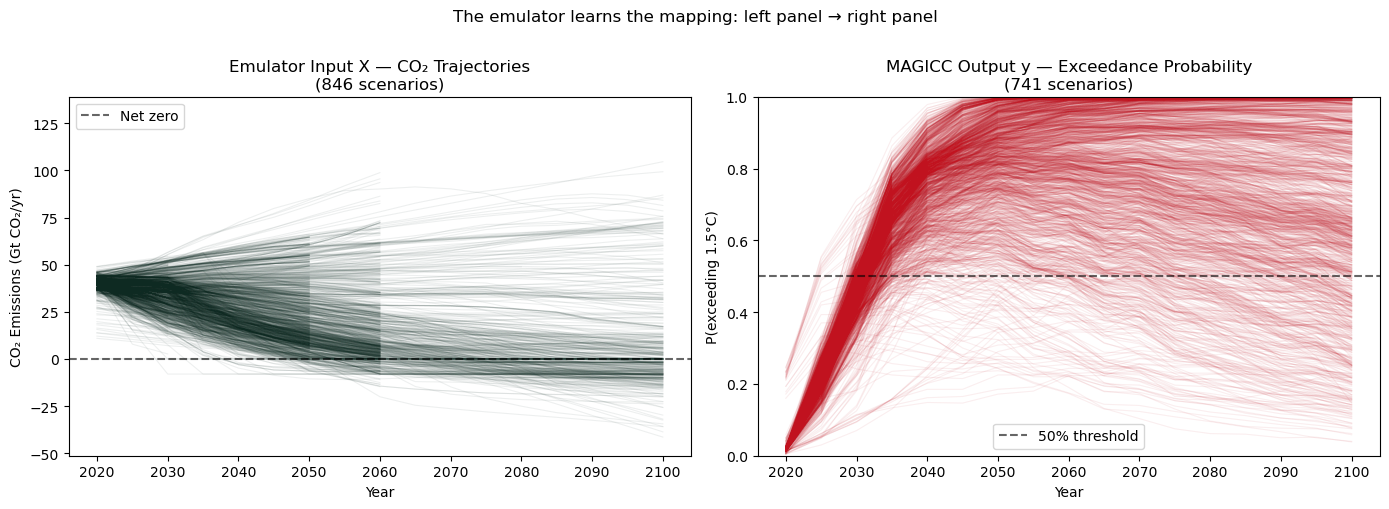

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for _, grp in df_co2_long.groupby(['Model', 'Scenario']):
    ax.plot(grp['Year'], grp['CO2_MtCO2yr'] / 1000,
            alpha=0.07, color=DARK_GREEN, linewidth=0.8)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.6, label='Net zero')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ Emissions (Gt CO₂/yr)')
ax.set_title(f"Emulator Input X — CO₂ Trajectories\n({df_co2_long['Scenario'].nunique()} scenarios)")
ax.legend()

ax = axes[1]
for _, grp in df_exc_long.groupby(['Model', 'Scenario']):
    ax.plot(grp['Year'], grp['Exceedance_1p5C'],
            alpha=0.07, color=RED, linewidth=0.8)
ax.axhline(0.5, color='black', linewidth=1.5, linestyle='--', alpha=0.6, label='50% threshold')
ax.set_xlabel('Year')
ax.set_ylabel('P(exceeding 1.5°C)')
ax.set_title(f"MAGICC Output y — Exceedance Probability\n({df_exc_long['Scenario'].nunique()} scenarios)")
ax.set_ylim(0, 1)
ax.legend()

fig.suptitle('The emulator learns the mapping: left panel → right panel', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Part 4 — Set Up the Emulator 🔧

| | Simulator (MAGICC) | Our emulator |
| :--- | :--- | :--- |
| **Input X** | CO₂ trajectory (17 values, 2020–2100) | Same |
| **Output y** | Exceedance probability trajectory (17 values) | Same |
| **How** | Physics equations | Random Forest trained on IAM data |
| **Speed** | Minutes | Milliseconds |

In [10]:
ml_data = df_co2.merge(df_exc, on=ID_COLS, suffixes=('_co2', '_exc'))
ml_data = ml_data.dropna()

X     = ml_data[[f'{yr}_co2' for yr in YEAR_COLS]].values  # shape: (n_scenarios, 17)
y     = ml_data[[f'{yr}_exc' for yr in YEAR_COLS]].values  # shape: (n_scenarios, 17)
years = [int(yr) for yr in YEAR_COLS]

print(f'Matched scenarios (have both CO₂ and exceedance data): {X.shape[0]:,}')
print(f'X shape: {X.shape}  — one CO₂ value per time step')
print(f'y shape: {y.shape}  — one exceedance probability per time step')

Matched scenarios (have both CO₂ and exceedance data): 456
X shape: (456, 17)  — one CO₂ value per time step
y shape: (456, 17)  — one exceedance probability per time step


---
## Part 5 — Train the Emulator 🤖

We use a **Random Forest Regressor**, which natively supports multi-output regression —
one forest that simultaneously predicts all 17 output years.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]:,} scenarios')
print(f'Test:  {X_test.shape[0]:,} scenarios\n')

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

overall_r2 = r2_score(y_test, y_pred, multioutput='uniform_average')
print(f'Overall R² (averaged across all 17 output years): {overall_r2:.3f}')

Train: 364 scenarios
Test:  92 scenarios

Overall R² (averaged across all 17 output years): 0.743


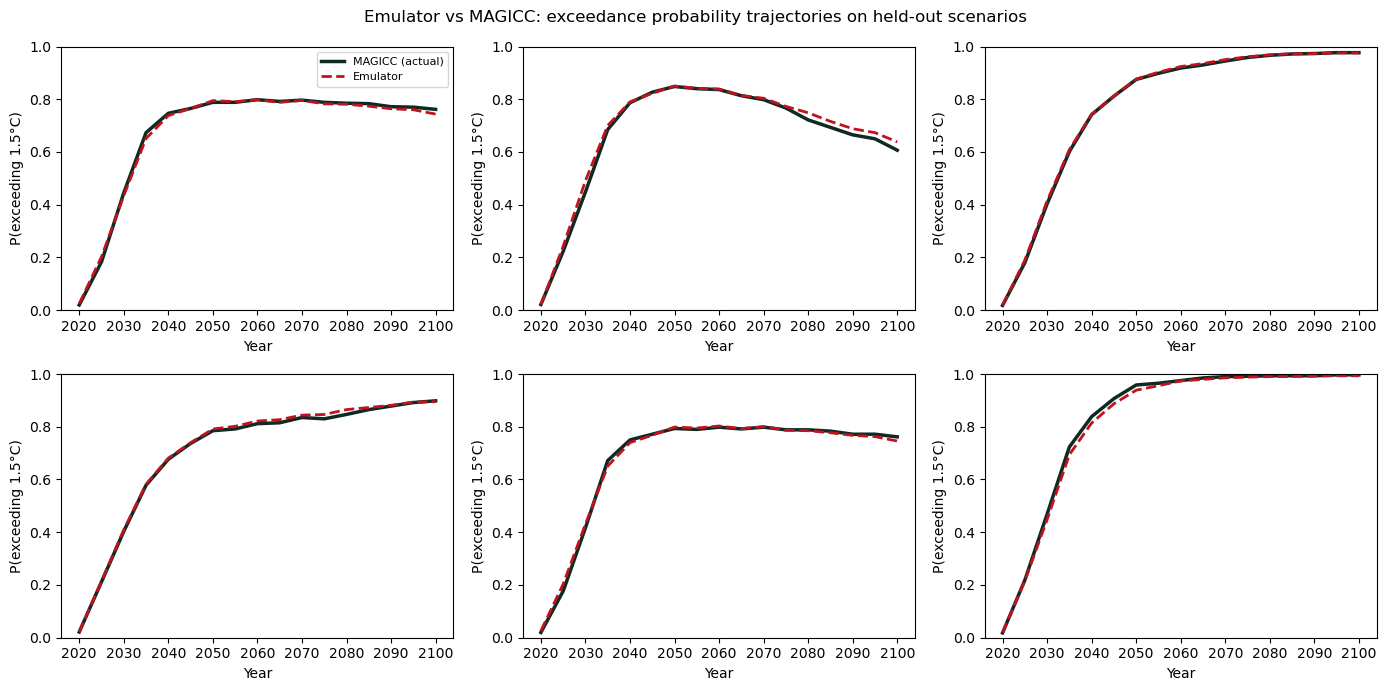


Each panel is a scenario the emulator has never seen.
Green = what MAGICC computed.  Red dashed = what our emulator predicted.


In [12]:
np.random.seed(42)
sample_idx = np.random.choice(X_test.shape[0], size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, idx in enumerate(sample_idx):
    ax = axes.flat[i]
    ax.plot(years, y_test[idx], color=DARK_GREEN, linewidth=2.5, label='MAGICC (actual)')
    ax.plot(years, y_pred[idx], color=RED, linewidth=2, linestyle='--', label='Emulator')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Year')
    ax.set_ylabel('P(exceeding 1.5°C)')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Emulator vs MAGICC: exceedance probability trajectories on held-out scenarios',
             fontsize=12)
plt.tight_layout()
plt.show()
print('\nEach panel is a scenario the emulator has never seen.')
print('Green = what MAGICC computed.  Red dashed = what our emulator predicted.')

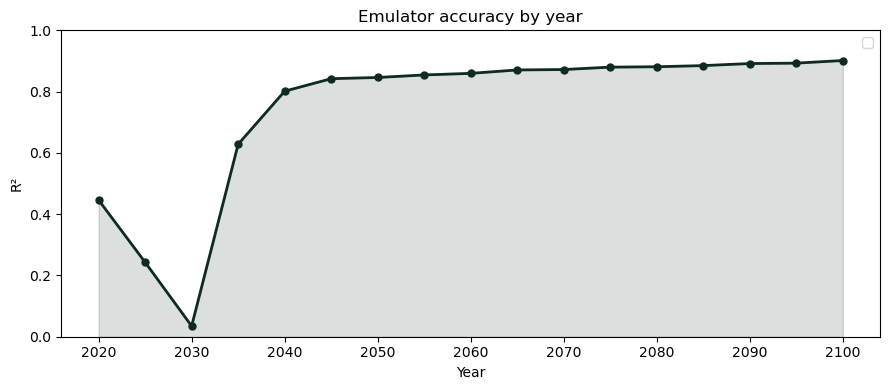

Best  R² at 2100: 0.902
Worst R² at 2030: 0.035


In [13]:
r2_per_year = [r2_score(y_test[:, t], y_pred[:, t]) for t in range(len(years))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(years, r2_per_year, color=DARK_GREEN, marker='o', markersize=5, linewidth=2)
ax.fill_between(years, r2_per_year, alpha=0.15, color=DARK_GREEN)
ax.set_xlabel('Year')
ax.set_ylabel('R²')
ax.set_ylim(0, 1)
ax.set_title('Emulator accuracy by year')
ax.legend()
plt.tight_layout()
plt.show()

worst_year = years[int(np.argmin(r2_per_year))]
best_year  = years[int(np.argmax(r2_per_year))]
print(f'Best  R² at {best_year}: {max(r2_per_year):.3f}')
print(f'Worst R² at {worst_year}: {min(r2_per_year):.3f}')

---
## Part 6 — Reflect 🧠

### What just happened?

You gave a Random Forest 17 CO₂ values and asked it to predict 17 exceedance probability values, the same mapping that the MAGICC emulator within IAMs computes. Trained on historical IAM scenarios, it closely replicated MAGICC outputs on held-out scenarios it had never seen.

---

### The correlated output problem

Our 17 output years are not independent, they form a time series, and consecutive years are strongly correlated. A scenario with high exceedance in 2050 will almost certainly have high exceedance in 2055. The overall trajectory has a characteristic shape: slow rise early, faster rise as emissions accumulate, eventually plateauing.

What our Random Forest does:
- A single set of trees is trained, where each split is chosen to reduce average impurity across *all 17 outputs simultaneously*
- Each leaf stores the average of all 17 output values for the training examples that reach it
- This creates implicit coupling — the same tree structure applies to all years — but it does not explicitly model the temporal relationships

What this misses:

| Issue | What it means |
| :--- | :--- |
| **Temporal smoothness** | RF predictions can wiggle year-to-year; MAGICC outputs are smooth by construction |
| **Monotonicity** | For many scenarios exceedance tends to increase over time; the RF has no knowledge of this |
| **Joint uncertainty** | Policy questions like "P(exceed 1.5°C before 2050 *and* 2°C before 2100)" require the *joint* distribution across years, not independent per-year predictions |

Better approaches to the multi-output problem:

1. **Predict trajectory parameters** — fit a parametric curve (e.g., a sigmoid) and predict its 2–3 parameters
2. **Gaussian process** — models the full joint distribution over years with a temporal covariance kernel. Produces calibrated uncertainty estimates and physically smooth trajectories.
3. **Recurrent model (LSTM / S4)** — explicitly uses the sequential ordering of outputs, learning how each year depends on the previous.

> 💡 **The general principle:** whenever your outputs are correlated, treating them as independent
> discards information about their joint structure. Here the correlation is near-perfect between
> adjacent years which means there's an enormous amount of structure our model is ignoring.

---

### Discussion questions

1. **Why does accuracy vary across years?** Near-term CO₂ emissions are similar across most scenarios — there's not much to differentiate them. Long-term CO₂ is where scenarios diverge. What does this mean for the information available to the emulator at different horizons?

2. **Is the R² realistic?** We used a random train/test split, so scenarios from the same IAM model appear in both. If you held out an entire model family (e.g., all MESSAGE scenarios) and evaluated on it, what would you expect to happen?

3. **What is missing from this emulator?**
   - CO₂ alone. MAGICC also takes CH₄, N₂O, aerosols, HFCs, and land-use CO₂.
   - Point predictions only. A real emulator must quantify its own uncertainty.
   - No temporal structure. A recurrent or physics-informed model could exploit year-to-year dependencies.

---

## 📝 Exercises

**A) Test a different threshold**  
Replace `VAR_EXC` with `'AR6 climate diagnostics|Exceedance Probability 2.0C|MAGICCv7.5.3'`.  
Retrain. Is 2°C exceedance easier or harder to predict from CO₂ alone? Why?

**B) Reduce the input**  
Use only 4 time steps as features: 2020, 2030, 2050, and 2100 (instead of all 17).  
How much does R² drop? What does this tell you about which parts of the trajectory carry the most information?

**C) Add more gases**  
Add `Emissions|CH4` as additional input features (a second block of 17 columns).  
Does methane improve accuracy?  
*Hint: add a third DuckDB query, merge on `ID_COLS`, and concatenate horizontally with `np.hstack`.*

**D) (Stretch) Evaluate by model family**  
Instead of a random split, hold out all scenarios from one IAM model (e.g., filter `Model.str.contains('MESSAGE')`).  
Train on the rest, evaluate on the held-out family.  
This asks: "Can the emulator generalise to a model it has never seen?"